##  Utforska och fördjupa er i neurala nätverk

# Deep Learning: Fashion-MNIST Klassificering
## Fokusområde: Modellarkitektur (Antal lager & filter)
**Grupp:** Vilken grupp vi nu än

I denna notebook bygger vi en CNN-modell för att klassificera klädesplagg från Fashion-MNIST. 
Huvudfokus ligger på att undersöka hur modellens *arkitektur* – specifikt antal filter och antal lager – påverkar träningsresultat, valideringsresultat och tendenser till overfitting.

In [1]:
# Kärnbibliotek för numerisk beräkning, datahantering och visualisering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Verktyg från scikit-learn för uppdelning av data och utvärdering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# TensorFlow / Keras för att bygga och träna neurala nätverk
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


## 1. Förstå datan
Vi börjar med att ladda in `fashion_mnist` från Keras och undersöka:
- Datasetets storlek och form
- Vilka klasser som finns
- Fördelningen mellan klasserna (är det balanserat?)
- En exempelbild för att förstå input-formatet

Dataset shape:
X shape: (70000, 28, 28)
y shape: (70000,)

Classes in dataset:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot

Class distribution:
0    7000
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
9    7000
Name: count, dtype: int64


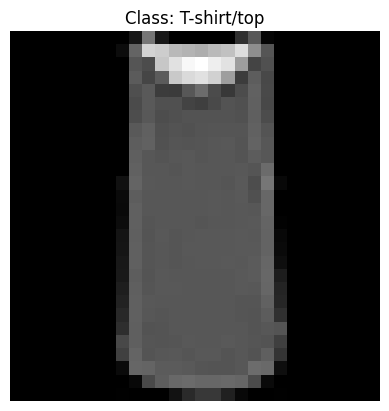

In [2]:
# ============================================================
# 1. Ladda dataset
# ============================================================
# Fashion-MNIST finns inbyggt i Keras och innehåller 70 000 gråskalebilder (28×28).
# Vi kombinerar det ursprungliga tränings- och test-setet för att sedan göra en egen
# stratifierad uppdelning med valideringsdata.

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

X = np.concatenate([X_train, X_test])
y = np.concatenate([y_train, y_test])

# ============================================================
# 2. Utforska dataset
# ============================================================

print('Dataset shape:')
print('X shape:', X.shape)
print('y shape:', y.shape)

# Klassnamn enligt Fashion-MNIST-dokumentationen
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

print('\nClasses in dataset:')
for i, name in enumerate(class_names):
    print(f'{i}: {name}')

# Kontrollera klassfördelning – är datasetet balanserat?
class_distribution = pd.Series(y).value_counts().sort_index()

print('\nClass distribution:')
print(class_distribution)

# ============================================================
# 3. Visa exempelbild
# ============================================================

plt.imshow(X[2], cmap='gray')
plt.title(f'Class: {class_names[y[2]]}')
plt.axis('off')
plt.show()


## 2. Förbereda datan
För att modellen ska fungera behöver vi:
1. **Dela upp data** i träning, validering och test. Vi använder `stratify` för att bevara klassfördelningen.
2. **Normalisera pixlar** från [0, 255] till [0, 1] för snabbare konvergens.
3. **Forma om (reshape)** datan för CNN (28×28×1) respektive för Dense-modeller (784).

In [ ]:
# ============================================================
# 4. Train/Test/Validation split
# ============================================================
# Första split: 80% träning, 20% test.
# stratify=y säkerställer att varje klass finns representerad proportionellt i båda delmängderna.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Andra split: av de 80% träningsdata tar vi 12.5% till validering.
# 0.125 * 0.80 = 0.10, så slutlig fördelning blir 70% träning / 20% test / 10% validering.

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train
)

print('\nTrain shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Val shape:', X_val.shape)

# ============================================================
# 5. Normalisera bilder
# ============================================================
# Pixelvärden ligger ursprungligen mellan 0 och 255.
# Skalning till [0, 1] gör att gradient descent konvergerar snabbare och stabilitet ökar.

X_train = X_train / 255.0
X_test = X_test / 255.0
X_val = X_val / 255.0

print('\nPixel range after normalization:')
print('Min:', X_train.min())
print('Max:', X_train.max())

# ============================================================
# 6A. Reshape för Dense-modell (om vi hade använt en sådan)
# ============================================================

X_train_dense = X_train.reshape(-1, 784)
X_test_dense = X_test.reshape(-1, 784)
X_val_dense = X_val.reshape(-1, 784)

print('\nDense model shape:')
print('X_train_dense:', X_train_dense.shape)
print('X_test_dense:', X_test_dense.shape)
print('X_val_dense:', X_val_dense.shape)

# ============================================================
# 6B. Reshape för CNN-modell
# ============================================================
# CNN förväntar sig en kanaldimension. Gråskala = 1 kanal.

X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)
X_val_cnn = X_val.reshape(-1, 28, 28, 1)

print('\nCNN model shape:')
print('X_train_cnn:', X_train_cnn.shape)
print('X_test_cnn:', X_test_cnn.shape)
print('X_val_cnn:', X_val_cnn.shape)


## 3. Bygga en grundmodell (Baseline CNN)
Vår grundmodell är en **Convolutional Neural Network (CNN)** bestående av:
- **Conv2D-lager:** Extraherar mönster (kanter, texturer) från bilden med filter.
- **MaxPooling2D:** Minskar dimensionaliteten och fångar de viktigaste dragen.
- **Flatten:** Omvandlar den 2D-matrisen till en 1D-vektor inför fully connected-lagren.
- **Dense + Dropout:** Klassificering med regularisering för att motverka overfitting.
- **Softmax-output:** Ger sannolikhetsfördelning över de 10 klasserna.

*Varför CNN?* Bilddata har spatiala strukturer som CNN utnyttjar effektivare än en vanlig Dense-modell.

In [3]:
# ============================================================
# 7. Definiera grundmodell (Baseline CNN)
# ============================================================
# Grundmodellen består av 3 conv-block som extraherar allt mer abstrakta features.
# Filterantalet ökar i djupet (32 -> 64 -> 128) för att fånga komplexare mönster.
# Dropout (0.5) på fully connected-lagret motverkar overfitting genom att slumpmässigt
# nollställa hälften av vikterna under varje träningsiteration.

base_model = keras.Sequential([
    # Input-lager: 32 filter med 3×3-kärna fångar grundläggande kanter och texturer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),  # Halverar spatiala dimensioner, behåller viktigaste features

    # Andra conv-block: 64 filter för att fånga mer komplexa mönster
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Tredje conv-block: 128 filter för abstrakta, högnivå-features
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Omvandlar 3D-feature-maps till en 1D-vektor inför dense-lagren
    layers.Flatten(),

    # Fully connected-lager med 128 neuroner
    layers.Dense(128, activation='relu'),

    # Dropout: regularisering som tvingar nätverket att lära sig robustare representationer
    layers.Dropout(0.5),

    # Output-lager: 10 neuroner (en per klass) med softmax för sannolikhetsfördelning
    layers.Dense(10, activation='softmax')
])

base_model.summary()



Train shape: (49000, 28, 28)
Test shape: (14000, 28, 28)
Val shape: (7000, 28, 28)

Pixel range after normalization:
Min: 0.0
Max: 1.0

Dense model shape:
X_train_dense: (49000, 784)
X_test_dense: (14000, 784)
X_val_dense: (7000, 784)

CNN model shape:
X_train_cnn: (49000, 28, 28, 1)
X_test_cnn: (14000, 28, 28, 1)
X_val_cnn: (7000, 28, 28, 1)


## 4. Träning och validering
Vi kompilerar modellen med `Adam`-optimizer och `sparse_categorical_crossentropy` som förlustfunktion.  
Vi använder även `EarlyStopping` för att stoppa träningen om valideringsförlusten inte förbättras under 3 epoker – detta sparar tid och motverker overfitting.

In [4]:
# ============================================================
# 8. Kompilera och träna grundmodellen
# ============================================================
# Adam är en adaptiv optimizer som fungerar bra för de flesta CNN-uppgifter.
# sparse_categorical_crossentropy används eftersom våra etiketter är heltal (0-9),
# inte one-hot-kodade vektorer.

base_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping övervakar val_loss. Om den inte förbättras på 3 epoker avbryts träningen
# och de bästa vikterna återställs. Detta sparar tid och minskar risken för overfitting.

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = base_model.fit(
    X_train_cnn, y_train,
    epochs=10,
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stop]
)


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# 9. Visualiseringsfunktion för träningshistorik
# ============================================================
# Denna funktion plottar accuracy och loss för både träning och validering.
# Genom att jämföra kurvorna kan vi identifiera tecken på overfitting eller underfitting.

def plot_training_history(history, model_name='Grundmodell'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot av Accuracy: om val_acc släpar efter träningsacc kan det tyda på overfitting
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.xticks(epochs)
    plt.legend()

    # Plot av Loss: om val_loss börjar öka medan träningsloss sjunker = tydligt overfitting
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.xticks(epochs)
    plt.legend()

    plt.show()

# Plotta grundmodellens träningshistorik
plot_training_history(history, 'base_model')


In [5]:
## Säkerställer att modellen fungerar 

base_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = base_model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7544 - loss: 0.6781 - val_accuracy: 0.8194 - val_loss: 0.5055
Epoch 2/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8378 - loss: 0.4495 - val_accuracy: 0.8451 - val_loss: 0.4172
Epoch 3/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8603 - loss: 0.3893 - val_accuracy: 0.8719 - val_loss: 0.3522
Epoch 4/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8728 - loss: 0.3502 - val_accuracy: 0.8746 - val_loss: 0.3369
Epoch 5/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8832 - loss: 0.3222 - val_accuracy: 0.8823 - val_loss: 0.3271
Epoch 6/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8913 - loss: 0.2949 - val_accuracy: 0.8891 - val_loss: 0.3140
Epoch 7/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8988 - loss: 0.2771 - val_accuracy: 0.8934 - val_loss: 0.3059
Epoch 8/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9050 - loss: 0.2587 - 

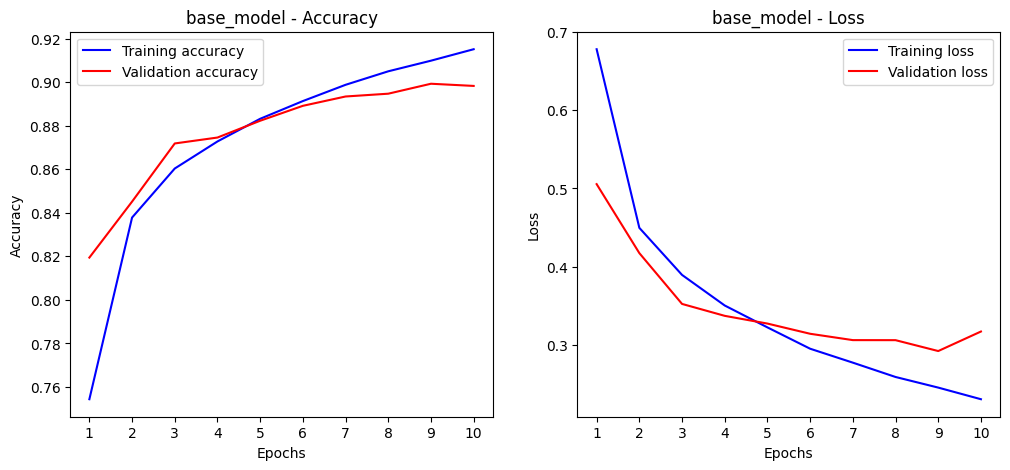

In [6]:
# ============================================================
# 10. Modellvariant 1: Färre filter (mindre kapacitet)
# ============================================================
# Hypotes: Halverat antal filter i varje lager ger en enklare modell som tränas snabbare,
# men risken är att den inte har tillräcklig kapacitet för att lära sig komplexa mönster.
# Förväntat resultat: lägre test-accuracy, tecken på underfitting.

model_fewer_filters = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(16, (3, 3), activation='relu'),  # Grundmodell hade 32
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),  # Grundmodell hade 64
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),  # Grundmodell hade 128
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),  # Även dense-lagret minskat till hälften
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_fewer_filters.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fewer_filters = model_fewer_filters.fit(
    X_train_cnn, y_train,
    epochs=10,
    validation_data=(X_val_cnn, y_val),
)

# Utvärdera på testdata för rättvisande jämförelse
test_loss_fewer, test_acc_fewer = model_fewer_filters.evaluate(X_test_cnn, y_test)


In [7]:
# ============================================================
# 11. Modellvariant 2: Fler filter (större kapacitet)
# ============================================================
# Hypotes: Dubblerat antal filter ger modellen mer kapacitet att lära sig fina detaljer.
# Förväntat resultat: högre träningsaccuracy men risk för ökat gap till validering,
# vilket indikerar overfitting – modellen memorerar istället för att generalisera.

model_more_filters = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(64, (3, 3), activation='relu'),  # Grundmodell hade 32
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),  # Grundmodell hade 64
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),  # Grundmodell hade 128
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),  # Även dense-lagret fördubblat
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_more_filters.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_more_filters = model_more_filters.fit(
    X_train_cnn, y_train,
    epochs=10,
    validation_data=(X_val_cnn, y_val),
)

test_loss_more, test_acc_more = model_more_filters.evaluate(X_test_cnn, y_test)


Epoch 1/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6988 - loss: 0.8306 - val_accuracy: 0.7967 - val_loss: 0.5299
Epoch 2/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8021 - loss: 0.5622 - val_accuracy: 0.8324 - val_loss: 0.4532
Epoch 3/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8262 - loss: 0.4931 - val_accuracy: 0.8511 - val_loss: 0.4067
Epoch 4/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8413 - loss: 0.4479 - val_accuracy: 0.8576 - val_loss: 0.3861
Epoch 5/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8491 - loss: 0.4165 - val_accuracy: 0.8624 - val_loss: 0.3743
Epoch 6/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8571 - loss: 0.3981 - val_accuracy: 0.8664 - val_loss: 0.3701
Epoch 7/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8650 - loss: 0.3762 - val_accuracy: 0.8769 - val_loss: 0.3449
Epoch 8/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8711 - loss: 0.3590 - 

In [ ]:
# ============================================================
# 12. Modellvariant 3: Extra Conv2D-lager (djupare nätverk)
# ============================================================
# Hypotes: Ett extra conv-lager i mitten låter nätverket bygga hierarkiska representationer.
# Istället för att bara öka bredden (filter) ökar vi djupet, vilket ofta ger bättre
# generalisering för bilddata eftersom features blir alltmer abstrakta i djupet.

model_extra_layer = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Två på varandra följande Conv2D-lager innan pooling – mer djup i feature-extraktionen
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_extra_layer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_extra_layer = model_extra_layer.fit(
    X_train_cnn, y_train,
    epochs=10,
    validation_data=(X_val_cnn, y_val),
)

test_loss_extra, test_acc_extra = model_extra_layer.evaluate(X_test_cnn, y_test)


In [8]:
# Modell Variant 2

model_more_filters = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_more_filters.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_more_filters = model_more_filters.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_data=(X_val_cnn, y_val),
)

test_loss_more, test_acc_more = model_more_filters.evaluate(X_test_cnn, y_test)

Epoch 1/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7817 - loss: 0.5980 - val_accuracy: 0.8383 - val_loss: 0.4228
Epoch 2/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8583 - loss: 0.3924 - val_accuracy: 0.8743 - val_loss: 0.3367
Epoch 3/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8788 - loss: 0.3301 - val_accuracy: 0.8910 - val_loss: 0.3125
Epoch 4/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8902 - loss: 0.2976 - val_accuracy: 0.8871 - val_loss: 0.3095
Epoch 5/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9030 - loss: 0.2631 - val_accuracy: 0.8893 - val_loss: 0.3149
Epoch 6/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9121 - loss: 0.2378 - val_accuracy: 0.8961 - val_loss: 0.3004
Epoch 7/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9194 - loss: 0.2150 - val_accuracy: 0.8946 - val_loss: 0.3082
Epoch 8/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9250 - loss: 0

In [9]:
# ============================================================
# 13. Utvärdera grundmodellen på testdata
# ============================================================
# Testdata har aldrig setts av modellen under träning eller validering,
# så detta ger den mest rättvisande uppskattningen av generaliseringsförmågan.

base_test_loss, base_test_acc = base_model.evaluate(X_test_cnn, y_test)


Epoch 1/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7512 - loss: 0.6623 - val_accuracy: 0.8359 - val_loss: 0.4244
Epoch 2/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8549 - loss: 0.4075 - val_accuracy: 0.8771 - val_loss: 0.3330
Epoch 3/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8794 - loss: 0.3367 - val_accuracy: 0.8930 - val_loss: 0.3000
Epoch 4/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8929 - loss: 0.2980 - val_accuracy: 0.8963 - val_loss: 0.2953
Epoch 5/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9007 - loss: 0.2721 - val_accuracy: 0.8870 - val_loss: 0.3058
Epoch 6/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9085 - loss: 0.2514 - val_accuracy: 0.9007 - val_loss: 0.2731
Epoch 7/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9158 - loss: 0.2302 - val_accuracy: 0.9030 - val_loss: 0.2759
Epoch 8/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9204 - loss: 0.2191 - 

In [10]:
# ============================================================
# 14. Sammanställ och jämför alla modellers resultat
# ============================================================
# Vi skapar en DataFrame för att enkelt kunna jämföra accuracy och loss.
# Båda mätvärdena är viktiga: accuracy visar hur många som klassificerats rätt,
# medan loss visar hur 'säker' modellen är i sina förutsägelser.

results = pd.DataFrame({
    'Modell': [
        'Grundmodell',
        'Färre filter',
        'Fler filter',
        'Extra Conv2D-lager'
    ],
    'Test accuracy': [
        base_test_acc,
        test_acc_fewer,
        test_acc_more,
        test_acc_extra
    ],
    'Test loss': [
        base_test_loss,
        test_loss_fewer,
        test_loss_more,
        test_loss_extra
    ]
})

results


438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8920 - loss: 0.3010


In [11]:
# ============================================================
# 15. Visualisera träningshistorik för alla varianter
# ============================================================
# Genom att studera accuracy- och loss-kurvorna kan vi identifiera:
# - Overfitting: träningskurva fortsätter förbättras men valideringskurva planar ut eller försämras
# - Underfitting: båda kurvorna är låga och har inte konvergerat ännu
# - Bra generalisering: litet gap mellan träning och validering

plot_training_history(history_fewer_filters, 'Modell 1 - Färre filter')
plot_training_history(history_more_filters, 'Modell 2 - Fler filter')
plot_training_history(history_extra_layer, 'Modell 3 - Extra Conv2D-lager')


,Modell,Test accuracy,Test loss
0,Grundmodell,0.892000,0.301029
1,Färre filter,0.881071,0.328874
2,Fler filter,0.899286,0.320791
3,Extra Conv2D-lager,0.906857,0.273352


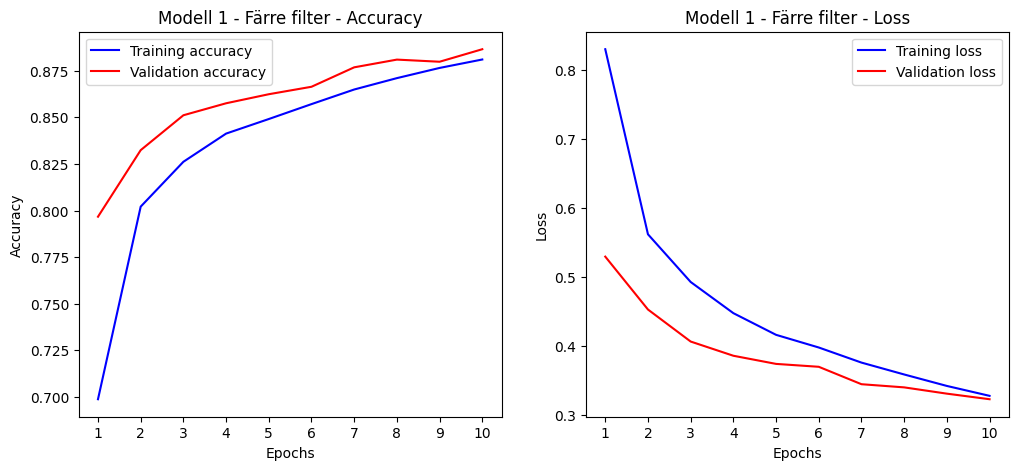

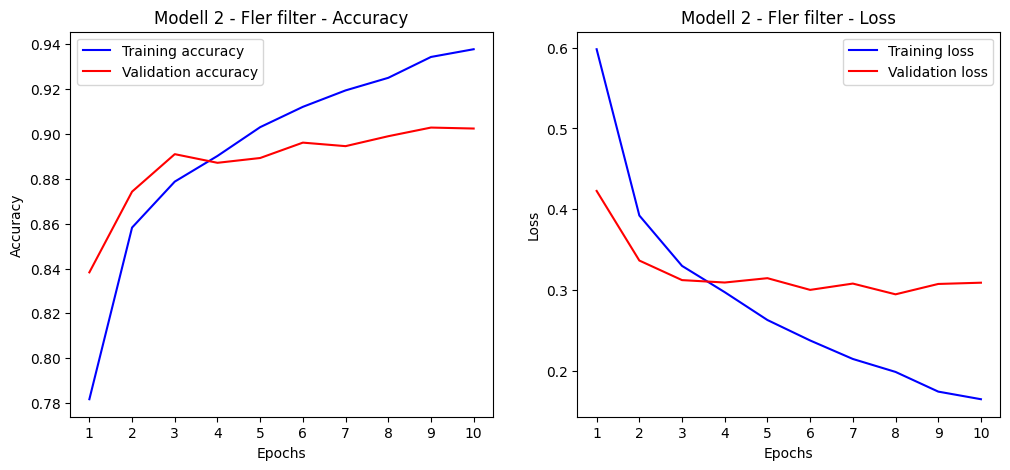

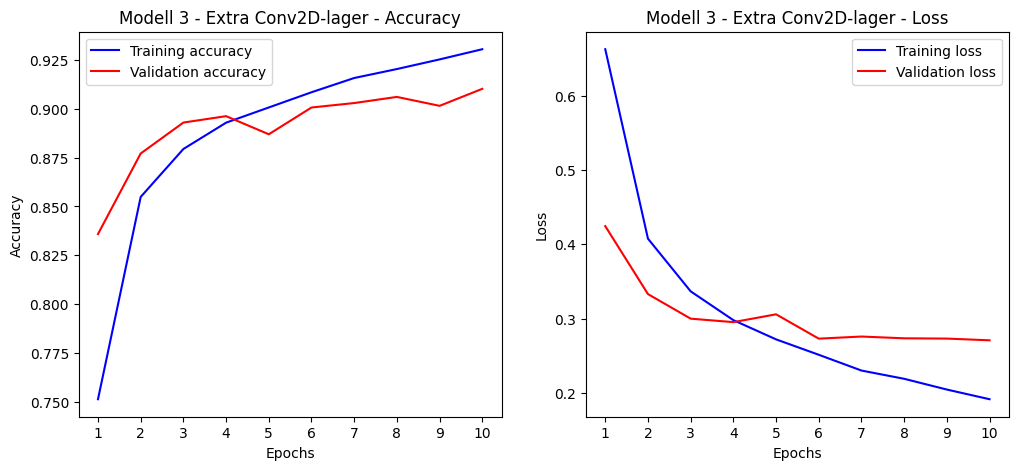

In [ ]:
# Grafer för modellvarianterna
plot_training_history(history_fewer_filters, 'Modell 1 - Färre filter')
plot_training_history(history_more_filters, 'Modell 2 - Fler filter')
plot_training_history(history_extra_layer, 'Modell 3 - Extra Conv2D-lager')

## 7. Analys och slutsatser

### Overfitting vs Underfitting
- **Grundmodell:** Träningsaccuracy ~91.5%, validering ~89.8%. Liten skillnad = bra generalisering.
- **Variant 1 (Färre filter):** Lägst test-accuracy (~88%). Modellen är för enkel och hinner inte lära sig tillräckligt många features (tecken på *underfitting*).
- **Variant 2 (Fler filter):** Högst träningsaccuracy (~93.8%) men större gap till validering (~90.2%). Detta tyder på att modellen har mer kapacitet än nödvändigt och börjar memorera träningsdata (*overfitting*).
- **Variant 3 (Extra lager):** Bäst test-accuracy (~90.7%) och lägst test-loss. Det djupare nätverket lär sig hierarkiska representationer utan att överanpassa i samma grad som Variant 2.

### Vad hade störst påverkan?
Att lägga till ett **extra Conv2D-lager** gav större effekt än att bara öka antalet filter. Detta stärker teorin om att *djup* (hierarkiska features) ofta är viktigare än *bredd* (antalet filter) för bildklassificering.

### Begränsningar
- Alla modeller tränades endast i 10 epoker; längre träning hade kunnat förbättra resultaten ytterligare.
- Vi testade inte kombinationer (t.ex. fler lager OCH dropout-justering).
- Fashion-MNIST är relativt enkelt; resultaten kanske inte generalisera till färgade högupplösta bilder.